dummy-spatialdata is compatible with both spatialdata == 0.5.0 (zarr v2) and 0.7.2 (zarr v3)

Thus please use 
1. conda create --name dummy_sd_env python==3.12 spatialdata==0.7.2
or 
2. conda create --name dummy_sd_env_05 python==3.12 spatialdata==0.5.0 setuptools==75.8.0

In [1]:
from dummy_spatialdata import generate_dataset
import dummy_anndata
import spatialdata_plot as sdp 
import spatialdata as sd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import tempfile as tf

/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [5]:
# generate spatialdata
sdata = generate_dataset(
    images = [
        {'type': 'rgb', 'scale_factors': [2,2,2], 'shape': {'x': 64, 'y': 64},
         'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']},
    ],
    labels = [
        {'n': 12, 'scale_factors': [2,2,2],  'shape': {'x': 64, 'y': 64},
         'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']},
        {'n': 12, 'scale_factors': [2,2,2],  'shape': {'x': 64, 'y': 64},
         'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']},
    ],
    shapes = [
        {'n': 12, 'type': 'polygon', 'shape': {'x': 64, 'y': 64},
         'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']},
        {'n': 12, 'type': 'circle', 'shape': {'x': 64, 'y': 64},
         'overlapping': False, 'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']}
    ],
    points = [
        {'n': 12, 'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']}
    ],
    tables = [
        {'table': dummy_anndata.generate_dataset(n_obs=12, n_vars=20), 'element': 'shape', 'element_index': 0},
        {'table': dummy_anndata.generate_dataset(n_obs=12, n_vars=20), 'element': 'shape', 'element_index': 1},
        {'table': dummy_anndata.generate_dataset(n_obs=12, n_vars=20), 'element': 'label', 'element_index': 0},
        {'table': dummy_anndata.generate_dataset(n_obs=12, n_vars=20), 'element': 'label', 'element_index': 1},
    ],
    coordinate_systems = {
        'identity': {'transformations': ['identity']},
        'scale': {'transformations': ['scale']},
        'mapAxis': {'transformations': ['mapAxis']},
        'translation': {'transformations': ['translation']},
        'rotation': {'transformations': ['rotation']},
        'affine': {'transformations': ['affine']},
        'sequence': {'transformations': ['scale', 'mapAxis', 'translation', 'rotation', 'affine']}
    },
    SEED=13
)
sdata

INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                
INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                


/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)
/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)
/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)
/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)


SpatialData object
├── Images
│     └── 'image_0': DataTree[cyx] (3, 64, 64), (3, 32, 32), (3, 16, 16), (3, 8, 8)
├── Labels
│     ├── 'label_0': DataTree[yx] (64, 64), (32, 32), (16, 16), (8, 8)
│     └── 'label_1': DataTree[yx] (64, 64), (32, 32), (16, 16), (8, 8)
├── Points
│     └── 'point_0': DataFrame with shape: (<Delayed>, 2) (2D points)
├── Shapes
│     ├── 'shape_0': GeoDataFrame shape: (12, 1) (2D shapes)
│     └── 'shape_1': GeoDataFrame shape: (12, 2) (2D shapes)
└── Tables
      ├── 'table_0': AnnData (12, 20)
      ├── 'table_1': AnnData (12, 20)
      ├── 'table_2': AnnData (12, 20)
      └── 'table_3': AnnData (12, 20)
with coordinate systems:
    ▸ 'affine', with elements:
        image_0 (Images), label_0 (Labels), label_1 (Labels), point_0 (Points), shape_0 (Shapes), shape_1 (Shapes)
    ▸ 'identity', with elements:
        image_0 (Images), label_0 (Labels), label_1 (Labels), point_0 (Points), shape_0 (Shapes), shape_1 (Shapes)
    ▸ 'mapAxis', with elements:
     

In [6]:
# write to temp
filename = tf.NamedTemporaryFile()
filename.name + ".zarr"
sdata.write(filename.name + ".zarr")

# read back
sdata = sd.read_zarr(filename.name + ".zarr")

/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/dask/utils.py:772: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)


INFO     The Zarr backing store has been changed from None the new file path:                                      
         /var/folders/vf/d8kg507x41xfh6z9vgv9skksdsn29w/T/tmp1escd124.zarr                                         


version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `shape_0` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table_0` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


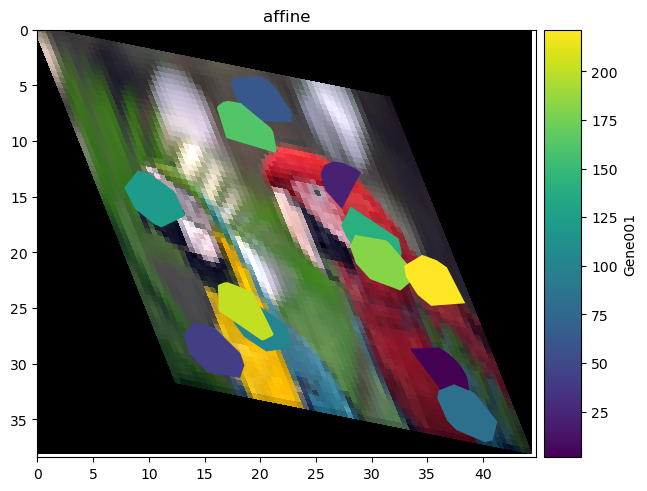

In [ ]:
sdata.pl.render_images('image_0').pl.render_shapes('shape_0', color='Gene001', table_name = 'table_0', table_layer = 'float_matrix').pl.show(coordinate_systems = 'affine')